In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully")

Libraries loaded successfully


In [34]:
df = pd.read_csv("titanic.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
print("=== Информация о датасете ===")
df.info()
print("\n=== Базовая статистика ===")
df.describe()

=== Информация о датасете ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

=== Базовая статистика ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [36]:
print("=== Пропущенные значения ===")
print(df.isnull().sum())
print(f"\nВыживаемость: {df['Survived'].value_counts().to_dict()}")

=== Пропущенные значения ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Выживаемость: {0: 549, 1: 342}


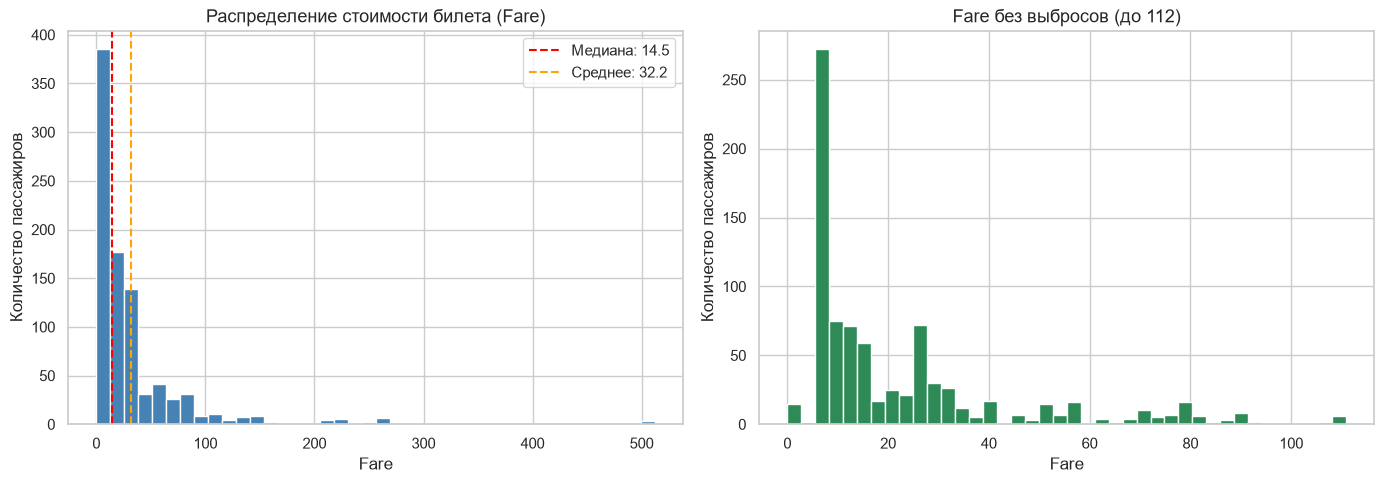

Мин: 0.00 | Макс: 512.33 | Медиана: 14.45 | Среднее: 32.20


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма Fare (все данные)
axes[0].hist(df["Fare"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение стоимости билета (Fare)", fontsize=13)
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Количество пассажиров")
axes[0].axvline(df["Fare"].median(), color="red", linestyle="--", label=f'Медиана: {df["Fare"].median():.1f}')
axes[0].axvline(df["Fare"].mean(), color="orange", linestyle="--", label=f'Среднее: {df["Fare"].mean():.1f}')
axes[0].legend()

# Гистограмма Fare без выбросов (до 95-го перцентиля)
fare_95 = df["Fare"].quantile(0.95)
axes[1].hist(df.loc[df["Fare"] <= fare_95, "Fare"], bins=40, color="seagreen", edgecolor="white")
axes[1].set_title(f"Fare без выбросов (до {fare_95:.0f})", fontsize=13)
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Количество пассажиров")

plt.tight_layout()
plt.show()

print(f"Мин: {df['Fare'].min():.2f} | Макс: {df['Fare'].max():.2f} | Медиана: {df['Fare'].median():.2f} | Среднее: {df['Fare'].mean():.2f}")

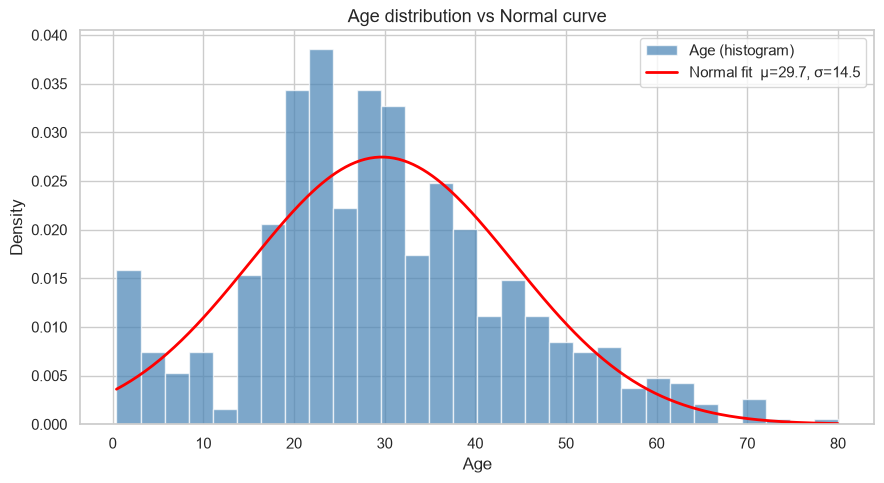

Shapiro-Wilk  W=0.9815, p=0.0000  → NOT normal (p<0.05)
Skewness : 0.388  (|skew| < 0.5 is roughly symmetric)
Kurtosis : 0.169  (excess; 0 = normal)


In [38]:
from scipy import stats
import numpy as np

age = df["Age"].dropna()
mu, sigma = age.mean(), age.std()

fig, ax = plt.subplots(figsize=(9, 5))

# Histogram (density=True so it shares scale with the PDF)
ax.hist(age, bins=30, density=True, color="steelblue", edgecolor="white", alpha=0.7, label="Age (histogram)")

# Normal curve fitted to sample mean and std
x = np.linspace(age.min(), age.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="red", linewidth=2, label=f"Normal fit  μ={mu:.1f}, σ={sigma:.1f}")

ax.set_title("Age distribution vs Normal curve", fontsize=13)
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Quantitative normality checks
stat_sw, p_sw = stats.shapiro(age.sample(min(len(age), 5000), random_state=42))
skew = stats.skew(age)
kurt = stats.kurtosis(age)   # excess kurtosis (0 = normal)
print(f"Shapiro-Wilk  W={stat_sw:.4f}, p={p_sw:.4f}  {'→ NOT normal (p<0.05)' if p_sw < 0.05 else '→ cannot reject normality'}")
print(f"Skewness : {skew:.3f}  (|skew| < 0.5 is roughly symmetric)")
print(f"Kurtosis : {kurt:.3f}  (excess; 0 = normal)")

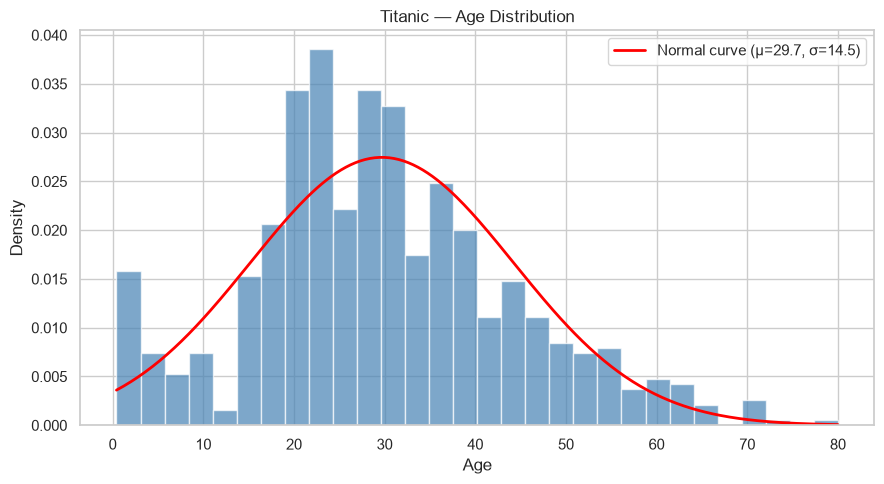

In [39]:
from scipy import stats
import numpy as np

age = df["Age"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(age, bins=30, density=True, color="steelblue", edgecolor="white", alpha=0.7)

x = np.linspace(age.min(), age.max(), 300)
ax.plot(x, stats.norm.pdf(x, age.mean(), age.std()), color="red", linewidth=2, label=f"Normal curve (μ={age.mean():.1f}, σ={age.std():.1f})")

ax.set_title("Titanic — Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
from scipy import stats
import numpy as np

age = df["Age"].dropna()

# --- Shapiro-Wilk test ---
W, p = stats.shapiro(age)

print("=" * 45)
print("       Shapiro-Wilk Normality Test")
print("=" * 45)
print(f"  W statistic : {W:.4f}")
print(f"  p-value     : {p:.4f}")
print("-" * 45)
if p < 0.05:
    print("  Result: REJECT normality (p < 0.05)")
    print("  The Age distribution is NOT normal.")
else:
    print("  Result: Cannot reject normality (p >= 0.05)")
    print("  The Age distribution may be normal.")
print("=" * 45)

       Shapiro-Wilk Normality Test
  W statistic : 0.9815
  p-value     : 0.0000
---------------------------------------------
  Result: REJECT normality (p < 0.05)
  The Age distribution is NOT normal.


## Shapiro-Wilk Test — What do W and p-value mean?

**Shapiro-Wilk** is a statistical test that checks whether your data follows a normal (bell-shaped) distribution.

---

### W statistic
- Ranges from **0 to 1**
- Measures how well your data matches a perfect normal distribution
- **W = 1.0** → perfectly normal
- **W close to 1** (e.g. 0.97+) → approximately normal
- **W far below 1** → significant deviation from normality

---

### p-value
- Answers the question: *"If the data were truly normal, how likely is it to get this W by chance?"*
- **p < 0.05** → reject normality — the data is significantly non-normal
- **p ≥ 0.05** → cannot reject normality — data is consistent with a normal distribution

---

### Result for Titanic Age
Even though the histogram looks roughly bell-shaped (W close to 1), the p-value is below 0.05 — so we **reject normality**. This happens because:
- There is a visible spike of infants/children near age 0
- The distribution has a slight right skew (more younger passengers)
- With a large sample (~700 values), the test is very sensitive to even small deviations

Mean age: 29.7  |  Std: 14.5

Z-score interpretation:
  Z =  0.0  → exactly at the mean (29.7 years)
  Z =  1.0  → 1 std above mean  (44.2 years)
  Z = -1.0  → 1 std below mean  (15.2 years)



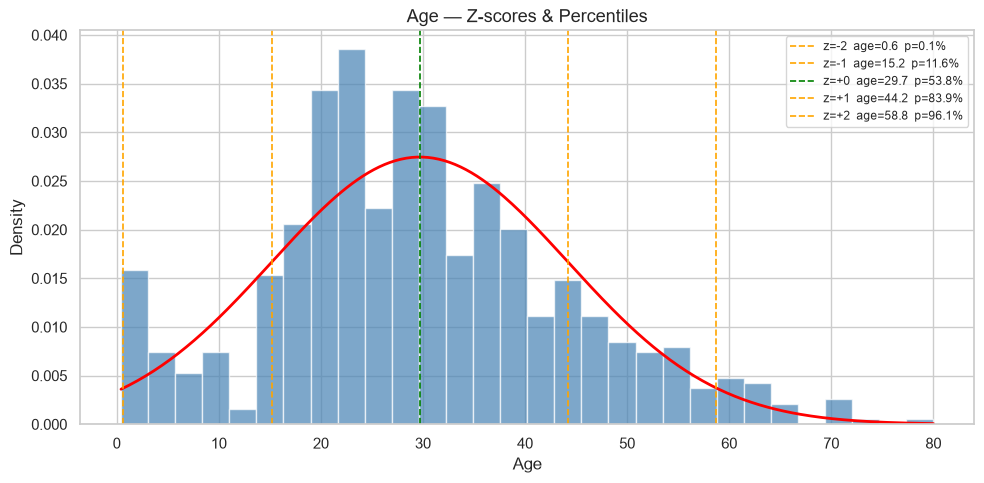


Sample rows from the full table:


,Age,Z-score,Percentile
0,0.42,-2.017,0.14
71,14.00,-1.081,10.43
142,19.00,-0.737,21.29
213,22.00,-0.530,30.53
284,25.00,-0.324,40.62
355,28.00,-0.117,49.02
426,31.00,0.090,58.82
497,36.00,0.434,71.22
568,41.00,0.778,79.76
639,49.00,1.330,89.29


In [41]:
from scipy import stats
import numpy as np

age = df["Age"].dropna().reset_index(drop=True)

# Z-scores
z_scores = stats.zscore(age)

# Percentiles
percentiles = stats.rankdata(age) / len(age) * 100

summary = pd.DataFrame({
    "Age": age,
    "Z-score": z_scores.round(3),
    "Percentile": percentiles.round(2)
}).sort_values("Age").reset_index(drop=True)

print(f"Mean age: {age.mean():.1f}  |  Std: {age.std():.1f}")
print(f"\nZ-score interpretation:")
print(f"  Z =  0.0  → exactly at the mean ({age.mean():.1f} years)")
print(f"  Z =  1.0  → 1 std above mean  ({age.mean() + age.std():.1f} years)")
print(f"  Z = -1.0  → 1 std below mean  ({age.mean() - age.std():.1f} years)")
print()

# Plot: histogram + z-score axis + percentile markers
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(age, bins=30, density=True, color="steelblue", edgecolor="white", alpha=0.7)

x = np.linspace(age.min(), age.max(), 300)
ax.plot(x, stats.norm.pdf(x, age.mean(), age.std()), color="red", linewidth=2)

# Mark z-score lines: -2, -1, 0, +1, +2
for z in [-2, -1, 0, 1, 2]:
    age_val = age.mean() + z * age.std()
    pct = stats.percentileofscore(age, age_val)
    ax.axvline(age_val, linestyle="--", linewidth=1.2,
               color="orange" if z != 0 else "green",
               label=f"z={z:+d}  age={age_val:.1f}  p={pct:.1f}%")

ax.set_title("Age — Z-scores & Percentiles", fontsize=13)
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend(fontsize=8.5, loc="upper right")
plt.tight_layout()
plt.show()

print("\nSample rows from the full table:")
display(summary.iloc[::len(summary)//10].head(11))